In [1]:
import os, time, copy, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, f1_score, classification_report

from PIL import Image

# Pour Grad-CAM / viz
import cv2

# Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

CONFIG = {
    'img_size': 224,            # conforme aux transforms officiels MobileNetV3
    'embed_dim': 128,           # taille embedding TRM
    'num_classes': 3,           # 0: Alert, 1: Drowsy, 2: Distracted
    'recursion_depth': 3,       # itérations du TRM
    'batch_size': 16,
    'lr': 1e-4,
    'epochs': 50,               # ajuste si besoin
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    'save_path': 'best_trm_model.pth',
    'lambda_ent': 0.05,         # régularisation entropie d'attention
    'lambda_phone': 0.5,        # poids de la perte auxiliaire phone_present
}
print("Device:", CONFIG['device'])

Device: cuda


In [2]:
# Téléchargement & parsing du Driver Inattention Detection Dataset (Kaggle)
import kagglehub

def download_and_prepare_annotations_final():
    """
    Télécharge le dataset de Kaggle et reconstruit (images, labels, subject_ids).
    Mapping 6 -> 3 classes :
      0: Dangerous -> Distracted(2)
      1: Distracted -> Distracted(2)
      2: Drinking  -> Distracted(2)
      3: Safe      -> Alert(0)
      4: Sleepy    -> Drowsy(1)
      5: Yawn      -> Drowsy(1)
    """
    print("--- Téléchargement & Parsing (Driver Inattention Detection Dataset) ---")
    path = kagglehub.dataset_download("zeyad1mashhour/driver-inattention-detection-dataset")

    id_map = {0:2, 1:2, 2:2, 3:0, 4:1, 5:1}
    image_paths, labels, subjects = [], [], []
    seen = set()

    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith('_annotations.txt'):
                annot_path = os.path.join(root, f)
                try:
                    with open(annot_path, 'r') as fh:
                        lines = fh.readlines()
                    for line in lines:
                        parts = line.strip().split(' ')
                        if len(parts) >= 2:
                            filename = parts[0]
                            try:
                                cls_id = int(parts[1].split(',')[-1])
                                if cls_id in id_map:
                                    img_path = os.path.join(root, filename)
                                    if os.path.exists(img_path) and img_path not in seen:
                                        image_paths.append(img_path)
                                        labels.append(id_map[cls_id])
                                        # subject_id = dossier parent de l'image (à adapter si autre structure)
                                        subjects.append(Path(img_path).parent.name)
                                        seen.add(img_path)
                            except:
                                continue
                except Exception as e:
                    print(f"Erreur lecture {f}: {e}")

    print(f"Total images chargées : {len(image_paths)}")
    return image_paths, labels, subjects

image_paths, labels, subjects = download_and_prepare_annotations_final()

--- Téléchargement & Parsing (Driver Inattention Detection Dataset) ---
Total images chargées : 14855


In [3]:
# Dataset PyTorch & transforms (séparées train/val)

import torchvision.transforms as T

def get_transforms(phase='train'):
    # Transforms conformes aux poids MobileNetV3 (224, mean/std ImageNet) [3](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.mobilenet_v3_small.html)
    if phase == 'train':
        return T.Compose([
            T.Resize(256),
            T.CenterCrop(224),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
            T.ToTensor(),
            T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            T.RandomErasing(p=0.2, scale=(0.02,0.2), ratio=(0.3,3.3))
        ])
    else:
        return T.Compose([
            T.Resize(256),
            T.CenterCrop(224),
            T.ToTensor(),
            T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])

class RealDriverDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        p = self.image_paths[idx]
        y = self.labels[idx]
        try:
            img = Image.open(p).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, torch.tensor(y, dtype=torch.long)
        except Exception as e:
            # image noire en cas d'erreur
            return torch.zeros((3, CONFIG['img_size'], CONFIG['img_size'])), torch.tensor(y, dtype=torch.long)

In [4]:
# Subject‑wise split (anti fuite d’identité) + DataLoaders

from collections import defaultdict
from sklearn.model_selection import train_test_split

def subject_wise_split(image_paths, labels, subjects, val_ratio=0.2, seed=42):
    """
    Split par sujets (et non par images) pour éviter la fuite d'identité. [1](https://docs.aws.amazon.com/prescriptive-guidance/latest/ml-operations-planning/splits-leakage.html)[2](https://link.springer.com/chapter/10.1007/978-3-031-45249-9_23)
    """
    # Regroupe indices par subject_id
    subject_to_indices = defaultdict(list)
    for i, s in enumerate(subjects):
        subject_to_indices[s].append(i)

    unique_subjects = list(subject_to_indices.keys())
    # split des sujets
    train_subj, val_subj = train_test_split(unique_subjects, test_size=val_ratio, random_state=seed, shuffle=True)

    train_idx, val_idx = [], []
    for s in train_subj:
        train_idx.extend(subject_to_indices[s])
    for s in val_subj:
        val_idx.extend(subject_to_indices[s])

    return train_idx, val_idx

train_idx, val_idx = subject_wise_split(image_paths, labels, subjects, val_ratio=0.2, seed=SEED)

# Crée deux datasets avec transforms distinctes
train_ds = RealDriverDataset([image_paths[i] for i in train_idx],
                             [labels[i] for i in train_idx],
                             transform=get_transforms('train'))

val_ds   = RealDriverDataset([image_paths[i] for i in val_idx],
                             [labels[i] for i in val_idx],
                             transform=get_transforms('val'))

print(f"Images d'entraînement : {len(train_ds)}")
print(f"Images de validation : {len(val_ds)}")

# WeightedRandomSampler (déséquilibre classes)
train_labels_tensor = torch.tensor([labels[i] for i in train_idx], dtype=torch.long)
class_counts = torch.bincount(train_labels_tensor, minlength=CONFIG['num_classes']).float()
class_weights = (len(train_labels_tensor) / (CONFIG['num_classes'] * class_counts)).to(torch.float32)
sample_weights = class_weights[train_labels_tensor]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False,
                          num_workers=0, pin_memory=True)

Images d'entraînement : 12933
Images de validation : 1922


In [5]:
# Architecture : MobileNetV3 Small → Adapter (128) → Tokens 7×7 → TRM + tête auxiliaire phone_present

import torchvision.models as models
from torchvision.models.mobilenetv3 import MobileNet_V3_Small_Weights

class PretrainedVisualEmbedding(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        # Poids officiels ImageNet
        self.backbone = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)  # [3](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.mobilenet_v3_small.html)
        self.features = self.backbone.features
        for p in self.features.parameters():
            p.requires_grad = True

        # 576 -> 128
        self.adapter = nn.Sequential(
            nn.Conv2d(576, output_dim, 1, bias=False),
            nn.BatchNorm2d(output_dim),
            nn.ReLU(inplace=True),
        )
        # 7x7 tokens (conforme 224)
        self.pool = nn.AdaptiveAvgPool2d((7, 7))

    def forward(self, x):
        x = self.features(x)               # [B, 576, H', W']
        x = self.adapter(x)                # [B, 128, H', W']
        x = self.pool(x)                   # [B, 128, 7, 7]
        B, C, H, W = x.shape
        x = x.view(B, C, -1).permute(0, 2, 1)  # [B, 49, 128]
        return x

class AttentionTRMBlock(nn.Module):
    def __init__(self, embed_dim, num_classes, num_heads=4):
        super().__init__()
        self.attn_norm = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads=num_heads, batch_first=True)
        self.ffn_norm = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, embed_dim)
        )
        self.head = nn.Linear(embed_dim, num_classes)
        self.gate = nn.Parameter(torch.tensor([1.0]))

    def forward(self, tokens, z_prev):
        g = torch.sigmoid(self.gate)
        z_curr = z_prev + g * tokens
        z_norm = self.attn_norm(z_curr)
        attn_out, attn_weights = self.attn(z_norm, z_norm, z_norm, average_attn_weights=False)
        z_curr = z_curr + attn_out
        z_curr = z_curr + self.ffn(self.ffn_norm(z_curr))
        return z_curr, self.head(z_curr[:, 0, :]), attn_weights

class DriverTRM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.embedding = PretrainedVisualEmbedding(config['embed_dim'])

        # 1 (CLS) + 49 tokens
        self.cls_token = nn.Parameter(torch.randn(1, 1, config['embed_dim']) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, 1 + 49, config['embed_dim']) * 0.02)

        self.trm_block = AttentionTRMBlock(config['embed_dim'], config['num_classes'])

        # Tête auxiliaire : présence téléphone (sigmoid)
        self.phone_head = nn.Linear(config['embed_dim'], 1)

    def forward(self, img):
        B = img.size(0)
        x_feat = self.embedding(img)                # [B,49,128]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls_tokens, x_feat], dim=1) + self.pos_embed  # [B,50,128]

        z_curr = torch.zeros_like(tokens, device=img.device)
        outputs_list, attn_last = [], None

        for _ in range(self.config['recursion_depth']):
            z_curr, logits, attn = self.trm_block(tokens, z_curr)
            outputs_list.append(logits)
            attn_last = attn

        phone_logit = self.phone_head(z_curr[:, 0, :])  # [B,1]
        return outputs_list, attn_last, phone_logit


In [6]:
# Pertes & utilitaires (Deep supervision, entropie attention, etc.)

from collections import Counter

def calculate_entropy(probs):
    eps = 1e-8
    entropy = -torch.sum(probs * torch.log(probs + eps), dim=1)
    return entropy.mean().item()

def deep_supervision_loss(outputs_list, targets, criterion):
    total = 0
    for out in outputs_list:
        total += criterion(out, targets)
    return total / len(outputs_list)

def attention_entropy_loss(attn_weights, lambda_ent=0.01):
    # [B, Heads, L, L] -> ligne CLS (0) vers patches (1:)
    probs = attn_weights[:, :, 0, 1:].clamp(min=1e-9)
    entropy = -(probs * probs.log()).sum(dim=-1).mean()
    return lambda_ent * entropy

In [7]:
# PLUS : Détecteur de téléphone pour pseudo‑labels

def phone_detector_stub(batch_imgs_tensor):
    """
    Stub: renvoie des 0. Remplace par les sorties de ton détecteur téléphone.
    Entrée: images tensorisées [B,3,224,224] (valeurs normalisées)
    Sortie: tensor [B] de 0/1
    """
    B = batch_imgs_tensor.size(0)
    return torch.zeros(B, dtype=torch.float32, device=batch_imgs_tensor.device)


In [8]:
# Entraînement (avec checkpointing & métriques)

import torch.optim as optim

def train_model(train_loader, val_loader, config, phone_detector=None):
    device = config['device']
    model = DriverTRM(config).to(device)

    # Poids de classes (sur train uniquement)
    all_train_labels = []
    for _, y in train_loader:
        all_train_labels.extend(y.tolist())
    counts = Counter(all_train_labels)
    total = sum(counts.values())
    class_weights = [total / (config['num_classes'] * counts[i]) for i in range(config['num_classes'])]
    class_weights_tensor = torch.FloatTensor(class_weights).to(device)
    print("Poids des classes:", [round(w,4) for w in class_weights])

    # Optims
    # LR différencié : backbone un peu plus bas
    param_groups = [
        {'params': model.embedding.features.parameters(), 'lr': config['lr'] * 0.5},
        {'params': list(model.embedding.adapter.parameters()) + 
                   list(model.trm_block.parameters()) + 
                   [model.cls_token, model.pos_embed] + 
                   list(model.phone_head.parameters()), 'lr': config['lr']}
    ]
    optimizer = torch.optim.AdamW(param_groups, lr=config['lr'], weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    criterion_ce = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_entropy': []}
    best_f1 = 0.0

    print(f"{'Epoch':^6} | {'Train':^10} | {'Val':^8} | {'Acc':^7} | {'F1':^7} | {'Ent':^6} | {'LR':^8}")
    print("-"*80)

    for epoch in range(config['epochs']):
        # ---- TRAIN ----
        model.train()
        running = 0.0

        for imgs, y in train_loader:
            imgs, y = imgs.to(device), y.to(device)
            optimizer.zero_grad()

            outputs_list, attn_w, phone_logit = model(imgs)

            loss_cls  = deep_supervision_loss(outputs_list, y, criterion_ce)
            loss_attn = attention_entropy_loss(attn_w, lambda_ent=config['lambda_ent'])

            # Pseudo-label téléphone si détecteur fourni
            if phone_detector is not None:
                with torch.no_grad():
                    phone_labels = phone_detector(imgs)  # tensor [B] (0/1)
                loss_phone = F.binary_cross_entropy_with_logits(phone_logit.squeeze(1), phone_labels)
            else:
                loss_phone = torch.tensor(0.0, device=device)

            loss = loss_cls + loss_attn + config['lambda_phone'] * loss_phone
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            running += loss.item()

        avg_train = running / len(train_loader)

        # ---- VAL ----
        model.eval()
        val_loss = 0.0
        val_entropy_sum = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for imgs, y in val_loader:
                imgs, y = imgs.to(device), y.to(device)
                outputs_list, _, phone_logit = model(imgs)

                loss = deep_supervision_loss(outputs_list, y, criterion_ce)
                val_loss += loss.item()

                final_logits = outputs_list[-1]
                probs = F.softmax(final_logits, dim=1)
                val_entropy_sum += calculate_entropy(probs)
                preds = torch.argmax(final_logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

        avg_val = val_loss / len(val_loader)
        avg_ent = val_entropy_sum / len(val_loader)
        val_acc = float(np.mean(np.array(all_preds) == np.array(all_labels)))
        val_f1  = f1_score(all_labels, all_preds, average='weighted')

        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_entropy'].append(avg_ent)

        save_msg = ""
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), config['save_path'])
            save_msg = " --> ⭐ Saved"

        print(f"{epoch+1:^6} | {avg_train:^10.4f} | {avg_val:^8.4f} | {val_acc:^7.4f} | {val_f1:^7.4f} | {avg_ent:^6.4f} | {current_lr:.1e}{save_msg}")

    print("Entraînement terminé.")
    return model, history

trained_model, history = train_model(train_loader, val_loader, CONFIG, phone_detector=None)  # remplace par ta fonction

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 110MB/s]


Poids des classes: [1.0117, 0.9929, 0.9956]
Epoch  |   Train    |   Val    |   Acc   |   F1    |  Ent   |    LR   
--------------------------------------------------------------------------------
  1    |   0.6806   |  0.4567  | 0.9105  | 0.9108  | 0.3984 | 5.0e-05 --> ⭐ Saved
  2    |   0.4341   |  0.4294  | 0.9303  | 0.9305  | 0.3309 | 5.0e-05 --> ⭐ Saved
  3    |   0.4016   |  0.4166  | 0.9438  | 0.9438  | 0.3131 | 5.0e-05 --> ⭐ Saved
  4    |   0.3773   |  0.4413  | 0.9282  | 0.9281  | 0.3958 | 5.0e-05
  5    |   0.3622   |  0.4037  | 0.9443  | 0.9445  | 0.3069 | 5.0e-05 --> ⭐ Saved
  6    |   0.3567   |  0.4204  | 0.9376  | 0.9376  | 0.3490 | 5.0e-05
  7    |   0.3471   |  0.3974  | 0.9501  | 0.9501  | 0.3661 | 5.0e-05 --> ⭐ Saved
  8    |   0.3427   |  0.4043  | 0.9396  | 0.9396  | 0.3238 | 5.0e-05
  9    |   0.3374   |  0.4104  | 0.9412  | 0.9411  | 0.3166 | 5.0e-05
  10   |   0.3324   |  0.3972  | 0.9501  | 0.9502  | 0.2863 | 5.0e-05 --> ⭐ Saved
  11   |   0.3345   |  0.3948  |

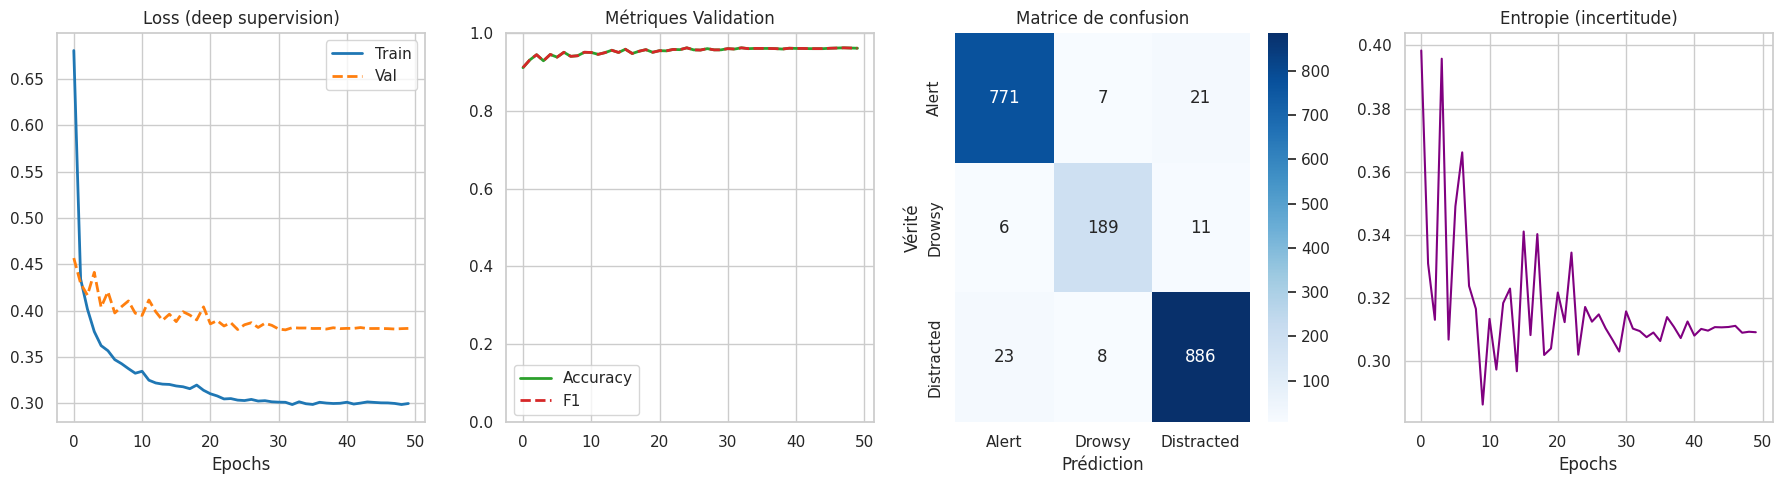


--- Rapport de Classification ---
              precision    recall  f1-score   support

       Alert       0.96      0.96      0.96       799
      Drowsy       0.93      0.92      0.92       206
  Distracted       0.97      0.97      0.97       917

    accuracy                           0.96      1922
   macro avg       0.95      0.95      0.95      1922
weighted avg       0.96      0.96      0.96      1922



In [9]:
# Plots (loss, métriques, matrice de confusion)

def plot_results(history, y_true, y_pred, classes=['Alert', 'Drowsy', 'Distracted']):
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(1, 4, figsize=(18,5))

    ax[0].plot(history['train_loss'], label='Train', color='tab:blue', lw=2)
    ax[0].plot(history['val_loss'], label='Val', color='tab:orange', lw=2, ls='--')
    ax[0].set_title("Loss (deep supervision)")
    ax[0].set_xlabel("Epochs"); ax[0].legend()

    ax[1].plot(history['val_acc'], label='Accuracy', color='tab:green', lw=2)
    ax[1].plot(history['val_f1'], label='F1', color='tab:red', lw=2, ls='--')
    ax[1].set_title("Métriques Validation"); ax[1].set_ylim(0,1.0); ax[1].legend()

    all_labels = range(len(classes))
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[2],
                xticklabels=classes, yticklabels=classes)
    ax[2].set_title("Matrice de confusion")
    ax[2].set_ylabel("Vérité"); ax[2].set_xlabel("Prédiction")

    ax[3].plot(history['val_entropy'], color='purple')
    ax[3].set_title("Entropie (incertitude)")
    ax[3].set_xlabel("Epochs")

    plt.tight_layout(); plt.show()

# Evaluation finale sur le set de validation
def evaluate_on_val(model, val_loader, classes=['Alert','Drowsy','Distracted']):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, y in val_loader:
            imgs = imgs.to(CONFIG['device'])
            outputs_list, _, _ = model(imgs)
            preds = torch.argmax(outputs_list[-1], dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    plot_results(history, all_labels, all_preds, classes)
    print("\n--- Rapport de Classification ---")
    print(classification_report(all_labels, all_preds, target_names=classes, labels=range(len(classes)), zero_division=0))

evaluate_on_val(trained_model, val_loader)

In [10]:
# Charger le meilleur modèle (checkpoint)

def load_best_model(config):
    model = DriverTRM(config).to(config['device'])
    state = torch.load(config['save_path'], map_location=config['device'])
    model.load_state_dict(state)
    model.eval()
    print(f"Checkpoint chargé: {config['save_path']}")
    return model

best_model = load_best_model(CONFIG)

Checkpoint chargé: best_trm_model.pth


Exemples de visualisation :


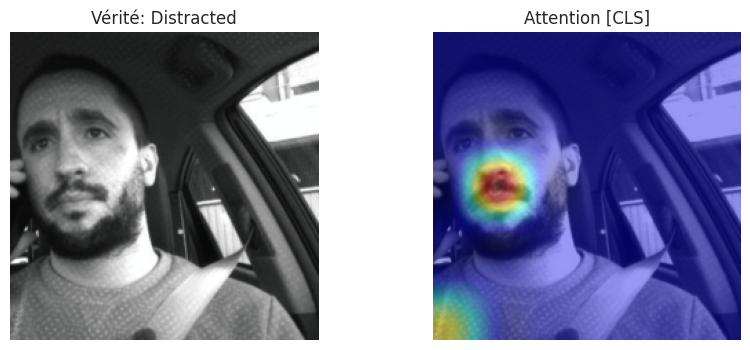

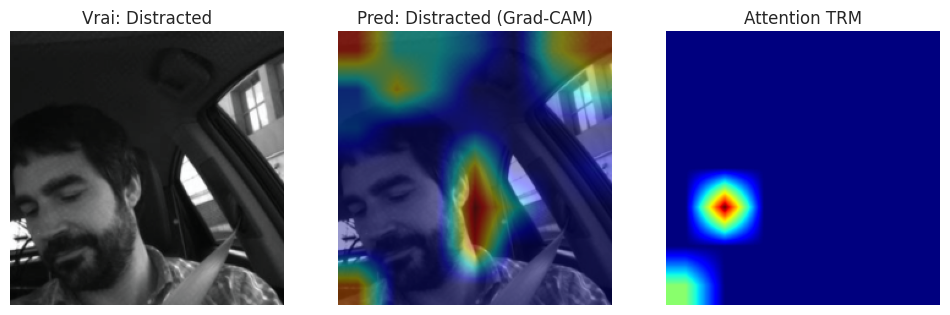

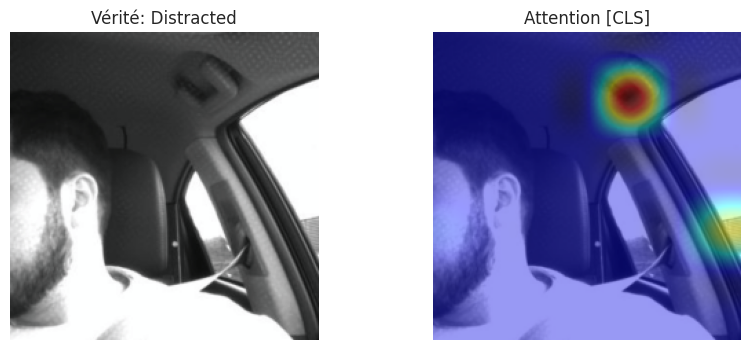

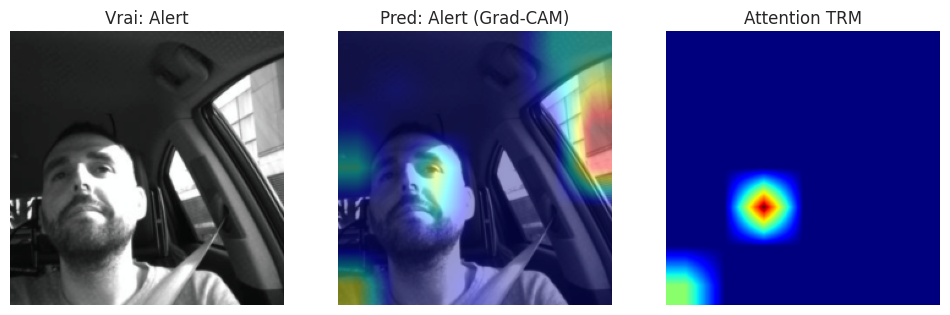

In [11]:
# Visualisations : Attention [CLS] (7×7) & Grad‑CAM

def visualize_attention(model, dataset, index=None):
    model.eval()
    if index is None:
        index = np.random.randint(0, len(dataset))

    img_tensor, label = dataset[index]
    img_display = img_tensor.permute(1,2,0).cpu().numpy()
    img_display = (img_display * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])).clip(0,1)
    img_display = (img_display*255).astype(np.uint8)

    img_in = img_tensor.unsqueeze(0).to(CONFIG['device'])
    with torch.no_grad():
        _, attn_weights, _ = model(img_in)
        cls_attn = attn_weights[0, :, 0, 1:].mean(dim=0).view(7,7).cpu().numpy()

    heatmap = cv2.resize(cls_attn, (img_display.shape[1], img_display.shape[0]), interpolation=cv2.INTER_CUBIC)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    heatmap = np.uint8(255*heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(cv2.cvtColor(img_display, cv2.COLOR_RGB2BGR), 0.6, heatmap_color, 0.4, 0)

    classes = {0:"Alert", 1:"Drowsy", 2:"Distracted"}
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img_display); plt.title(f"Vérité: {classes[label.item()]}"); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title("Attention [CLS]"); plt.axis('off')
    plt.show()

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activation = None
        self.h1 = target_layer.register_forward_hook(self.save_activation)
        self.h2 = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activation = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        self.model.eval()
        with torch.set_grad_enabled(True):
            outputs, _, _ = self.model(x)
            logit = outputs[-1]
            if class_idx is None:
                class_idx = torch.argmax(logit, dim=1)
            self.model.zero_grad()
            target = logit[0, class_idx]
            target.backward()

            pooled_grad = torch.mean(self.gradients, dim=[0,2,3])
            activation = self.activation[0]
            for i in range(activation.shape[0]):
                activation[i] *= pooled_grad[i]

            heatmap = torch.mean(activation, dim=0).cpu().detach().numpy()
            heatmap = np.maximum(0, heatmap)
            if heatmap.max() > 0:
                heatmap = heatmap / heatmap.max()
            return heatmap, class_idx.item()

def visualize_gradcam(model, dataset, index=None):
    if index is None: index = np.random.randint(0, len(dataset))

    img_tensor, label = dataset[index]
    inp = img_tensor.unsqueeze(0).to(CONFIG['device'])
    inp.requires_grad = True

    # Cible = dernière couche conv du backbone
    target_layer = model.embedding.features[-1]  # Grad-CAM canonique sur dernière conv [6](https://openaccess.thecvf.com/content_ICCV_2017/papers/Selvaraju_Grad-CAM_Visual_Explanations_ICCV_2017_paper.pdf)
    cam = GradCAM(model, target_layer)
    heatmap, pred_idx = cam(inp)

    # Prépare image
    img_disp = img_tensor.permute(1,2,0).cpu().numpy()
    img_disp = (img_disp * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])).clip(0,1)
    img_disp = (img_disp*255).astype(np.uint8)

    heatmap = cv2.resize(heatmap, (img_disp.shape[1], img_disp.shape[0]))
    heatmap = np.uint8(255*heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(cv2.cvtColor(img_disp, cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)

    classes = {0:"Alert", 1:"Drowsy", 2:"Distracted"}
    plt.figure(figsize=(12,5))
    plt.subplot(1,3,1); plt.imshow(img_disp); plt.title(f"Vrai: {classes[label.item()]}"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title(f"Pred: {classes[pred_idx]} (Grad-CAM)"); plt.axis('off')
    with torch.no_grad():
        _, attn = model(inp)[0:2]
        cls_attn = attn[0, :, 0, 1:].mean(dim=0).view(7,7).cpu().numpy()
        cls_attn = cv2.resize(cls_attn, (img_disp.shape[1], img_disp.shape[0]))
        plt.subplot(1,3,3); plt.imshow(cls_attn, cmap='jet'); plt.title("Attention TRM"); plt.axis('off')
    plt.show()

print("Exemples de visualisation :")
for _ in range(2):
    visualize_attention(best_model, val_ds)
    visualize_gradcam(best_model, val_ds)